In [1]:
import os

import yaml
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import torch

# Change the current working directory to the directory containing the config file
os.chdir("..")

In [2]:
datasets = {
    "W wide mass": {
        # "graphs_file": "/eos/home-t/tmlinare/Lund/Lund_tagging/lundtoptagger_data/graphs/ln_kT_cut_None_with_pt_new_pt_weights_2025-03-07/graphs_Wwidemass_1-2_ln_kT_cut_None_with_pt",
        "graphs_file": "/eos/home-t/tmlinare/Lund/Lund_tagging/lundtoptagger_data/graphs/ln_kT_cut_None_with_pt_200_with_dsids_mcweights_new_pt_weights_2025-03-07/graphs_Wwidemass_1-2_ln_kT_cut_None_with_pt_200_with_dsids_mcweights_new_pt_weights_2025-03-07",
        "ROOT_file": '/eos/home-t/tmlinare/Lund/jetetmiss/JETMDataMC/jpierre/run/submitDir-2025-01-06-1052-fee0 files 1-50/data-ANALYSIS/mc20_13TeV.802017.Py8EG_A14NNPDF23LO_WprimeWZ_flatpT_wideWmass.deriv.DAOD_JETM2.e8482_s3797_r13145_p5548.root',
        "config_signal": "W_flat"
    },
    "W real mass": {
        # "graphs_file": "/eos/home-t/tmlinare/Lund/Lund_tagging/lundtoptagger_data/graphs/ln_kT_cut_None_with_pt_new_pt_weights_2025-03-07/graphs_Wrealmass_3-4_ln_kT_cut_None_with_pt"
        "graphs_file": "/eos/home-t/tmlinare/Lund/Lund_tagging/lundtoptagger_data/graphs/ln_kT_cut_None_with_pt_200_with_dsids_mcweights_new_pt_weights_2025-03-07/graphs_Wrealmass_1-2_ln_kT_cut_None_with_pt_200_with_dsids_mcweights_new_pt_weights_2025-03-07",
        "config_signal": "W"
    }
}

Dataset: W wide mass
Selected parameters for signal: W_flat

Using histogram file: ./histos/WBSMP8_flat.root
Check if the data used to create the histogram contains jets with pT below the config file minimum.
If not, then the count for the first non-zero bin in the histogram is too low and results in the calculated flat-pT weights being too high for low-pT jets.
Different mass cuts result in different pT distributions.

Loading graphs file: /eos/home-t/tmlinare/Lund/Lund_tagging/lundtoptagger_data/graphs/ln_kT_cut_None_with_pt_200_with_dsids_mcweights_new_pt_weights_2025-03-07/graphs_Wwidemass_1-2_ln_kT_cut_None_with_pt_200_with_dsids_mcweights_new_pt_weights_2025-03-07
Jets with pT outside this range may not have correct weights applied.
Minimum pT in dataset: 200.188890625 GeV, Maximum pT in dataset: 3199.56825 GeV.
Check if the dataset is correctly filtered to match the config file parameters.
Minimum mass in dataset: 0.5393209228515625 GeV, Maximum mass in dataset: 1755.222375 GeV.

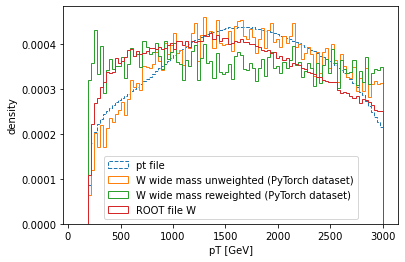

Dataset: W real mass
Selected parameters for signal: W

Using histogram file: ./histos/WBSMP8.root
Check if the data used to create the histogram contains jets with pT below the config file minimum.
If not, then the count for the first non-zero bin in the histogram is too low and results in the calculated flat-pT weights being too high for low-pT jets.
Different mass cuts result in different pT distributions.

Loading graphs file: /eos/home-t/tmlinare/Lund/Lund_tagging/lundtoptagger_data/graphs/ln_kT_cut_None_with_pt_200_with_dsids_mcweights_new_pt_weights_2025-03-07/graphs_Wrealmass_1-2_ln_kT_cut_None_with_pt_200_with_dsids_mcweights_new_pt_weights_2025-03-07
Jets with pT outside this range may not have correct weights applied.
Minimum pT in dataset: 200.550453125 GeV, Maximum pT in dataset: 3199.42725 GeV.
Check if the dataset is correctly filtered to match the config file parameters.
Minimum mass in dataset: 0.6144024658203125 GeV, Maximum mass in dataset: 1497.652625 GeV.
Check if 

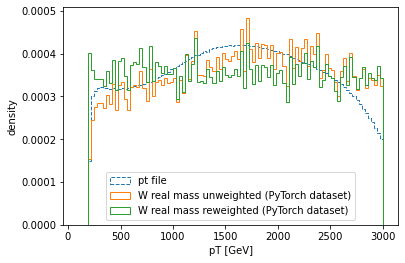

In [3]:
hist_params = dict(bins=100, histtype="step", density=True)

for dataset_label in datasets:
    print("Dataset:", dataset_label)

    # get the signal configuration from the YAML file
    with open("configs/config_signal.yaml") as f:
        config_signal = yaml.load(f, Loader=yaml.FullLoader)
    signal = datasets[dataset_label]["config_signal"]
    print("Selected parameters for signal:", signal)
    pt_min, pt_max = config_signal[signal]["pt_range"]
    m_min, m_max = config_signal[signal]["mass_range"]

    # plot histogram from hist file
    hist_filename = config_signal[signal]["pt_hist_file_signal"]
    print("\nUsing histogram file:", hist_filename)
    hist_file = uproot.open(hist_filename)

    bin_counts, bin_edges = hist_file["pt"].to_numpy()
    hist_pt_min_nonzero = bin_edges[np.nonzero(bin_counts)[0][0]]
    hist_pt_max_nonzero = bin_edges[np.nonzero(bin_counts)[0][-1]+1]

    bin_counts_mass, bin_edges_mass = hist_file["mass"].to_numpy()
    hist_mass_min_nonzero = bin_edges_mass[np.nonzero(bin_counts_mass)[0][0]]
    hist_mass_max_nonzero = bin_edges_mass[np.nonzero(bin_counts_mass)[0][-1]+1]

    if hist_pt_min_nonzero > pt_min or hist_pt_max_nonzero < pt_max:
        print(f"WARNING: pT histogram range with non-zero bin counts, {hist_pt_min_nonzero}-{hist_pt_max_nonzero} GeV, does not cover the config file range {pt_min}-{pt_max} GeV.")
    if hist_pt_min_nonzero < pt_min:
        print(f"WARNING: pT histogram range with non-zero bin counts starts at {hist_pt_min_nonzero} GeV, which is below the config file minimum {pt_min} GeV.")
        print("Check if the data used to create the histogram contains jets with pT below the config file minimum.")
        print("If not, then the count for the first non-zero bin in the histogram is too low and results in the calculated flat-pT weights being too high for low-pT jets.")

    if hist_mass_min_nonzero != m_min or hist_mass_max_nonzero != m_max:
        print(f"WARNING: mass histogram range with non-zero bin counts, {hist_mass_min_nonzero}-{hist_mass_max_nonzero} GeV, does not match file range {m_min}-{m_max} GeV.")
        print("Different mass cuts result in different pT distributions.")

    hist_params["bins"] = bin_edges
    plt.hist(bin_edges[:-1], weights=bin_counts, label="pt file", linestyle="--", **hist_params)

    # plot pT distribution from PyTorch dataset
    graphs_filname = datasets[dataset_label]["graphs_file"]
    print("\nLoading graphs file:", graphs_filname)
    dataset = torch.load(graphs_filname)
    pts = np.array([jet.pt for jet in dataset])
    masses = np.array([jet.mass for jet in dataset])
    weights = np.array([jet.weights for jet in dataset])
    ys = np.array([jet.y for jet in dataset])

    if pts.min() < pt_min or pts.max() > pt_max:
        # TODO: or should I compare with hist_pt_min_nonzero and hist_pt_max_nonzero?
        print(f"WARNING: pT values in dataset are outside the configured range {pt_min}-{pt_max} GeV.")
        print("Jets with pT outside this range may not have correct weights applied.")
        print(f"Minimum pT in dataset: {pts.min()} GeV, Maximum pT in dataset: {pts.max()} GeV.")
        print("Check if the dataset is correctly filtered to match the config file parameters.")

    if masses.min() < m_min or masses.max() > m_max:
        # TODO: or should I compare with hist_pt_min_nonzero and hist_pt_max_nonzero?
        print(f"WARNING: mass values in dataset are outside the configured range {m_min}-{m_max} GeV.")
        print(f"Minimum mass in dataset: {masses.min()} GeV, Maximum mass in dataset: {masses.max()} GeV.")
        print("Check if the dataset is correctly filtered to match the config file parameters.")

    plt.hist(pts[ys==1], **hist_params, label=dataset_label+" unweighted (PyTorch dataset)")
    plt.hist(pts[ys==1], weights=weights[ys==1], **hist_params, label=dataset_label+" reweighted (PyTorch dataset)")

    # plot pT distribution from original ROOT file
    if "ROOT_file" in datasets[dataset_label]:
        signal_jet_truth_label = config_signal[signal]["signal_jet_truth_label"]

        ROOT_file = datasets[dataset_label]["ROOT_file"]
        print("\nLoading ROOT file:", ROOT_file)

        with uproot.open(ROOT_file) as infile:
            tree = infile["AnalysisTree"]
            jet_pts = ak.flatten(tree["LRJ_pt"].array(library="ak"))
            jet_masses = ak.flatten(tree["LRJ_mass"].array(library="ak"))
            truth_labels = ak.flatten(tree["LRJ_truthLabel"].array(library="ak"))

        mass_selection = (jet_masses > m_min) & (jet_masses < m_max)
        plt.hist(jet_pts[(truth_labels==signal_jet_truth_label) & mass_selection], label="ROOT file W", **hist_params)

    plt.xlabel("pT [GeV]")
    plt.ylabel("density")
    plt.legend()
    # plt.savefig(f"tests/pt_hist_{dataset_label.replace(' ', '_')}.pdf")
    plt.show()

In [4]:
with open("configs/config_signal.yaml") as f:
    config = yaml.load(f, Loader=yaml.FullLoader)
# signal = config["signal"]
signal = "W_flat"

# function from utils_newdata, modified to return some additional values
def GetPtWeight_2(truth_labels, pts, SF):

    ## PT histograms of all qcd and top jets in dataset
    filename1 = config[signal]["pt_hist_file_bkg"]
    filename2 = config[signal]["pt_hist_file_signal"]
    weights_file1 = uproot.open(filename1)
    flatweights_bg = weights_file1["pt"].to_numpy()
    weights_file2 = uproot.open(filename2)
    flatweights_sig = weights_file2["pt"].to_numpy()
    
    lenght_sig = len(flatweights_sig[0])
    lenght_bkg = len(flatweights_bg[0])
    #print("lenght_sig:", lenght_sig, "  lenght_bkg:", lenght_bkg)
    
    sig_bkg_proportion = 5  ## if is taked 5% of signal and 1% of qcd for training then sig_bkg_proportion=5
    scale_factor = (lenght_bkg/lenght_sig) / sig_bkg_proportion #1
    #print("scale_factor", scale_factor)
    
    weight_out = []
    Inv_hist_bg = []#flatweights_bg[0]
    Inv_hist_sig = []#flatweights_sig[0]
    
    ## it's time to calcuate the 1/hist
    for i in range (0,lenght_bkg):
        if flatweights_bg[0][i]==0:
            Inv_hist_bg.append(0)
            continue
        else:
            Inv_hist_bg.append(np.sum(flatweights_bg[0]) / (lenght_bkg * flatweights_bg[0][i]))
            
    for i in range (0,lenght_sig):
        if flatweights_sig[0][i]==0:
            Inv_hist_sig.append(0)
            continue
        else:
            Inv_hist_sig.append(np.sum(flatweights_sig[0]) / (lenght_sig * flatweights_sig[0][i]))

    for i in range(len(truth_labels)):
        pt_bin = int( ((pts[i]-100)/3000)*lenght_sig )
        if pt_bin>=lenght_sig : # ==
            pt_bin = lenght_sig-1
        if truth_labels[i]==10: # background could also be identified by DSIS, which would be < 370000
            #print("pt[i] ->", pt[i])
            #print("bin_pt->", pt_bin)
            weight_out.append( (Inv_hist_bg[pt_bin])*1  )
        if truth_labels[i]!=10: # this could also contain some non-signal jets which must be removed when creating the training dataset
            weight_out.append( (Inv_hist_sig[pt_bin]*scale_factor)*1 ) #*10**2 )
    return np.array(weight_out), Inv_hist_bg, Inv_hist_sig

In [5]:
# TODO: currently just using the values from the last file in the file dict; either do it for all files or explicitly set which one to use
flat_weights, Inv_hist_bg, Inv_hist_sig = GetPtWeight_2(truth_labels, jet_pts, 5)

In [6]:
flat_weights

array([0.15991322, 0.16155624, 0.1576814 , ..., 0.32015054, 0.15769446,
       0.15834643])

Text(0.5, 0, 'pT bin')

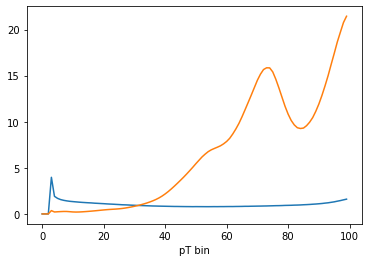

In [7]:
plt.plot(Inv_hist_sig, label="signal")
plt.plot(Inv_hist_bg, label="background")
plt.xlabel("pT bin")

Dataset: W wide mass
Selected parameters for signal: W_flat

Using histogram file: ./histos/WBSMP8_flat.root
Check if the data used to create the histogram contains jets with pT below the config file minimum.
If not, then the count for the first non-zero bin in the histogram is too low and results in the calculated flat-pT weights being too high for low-pT jets.
Different mass cuts result in different pT distributions.

Loading graphs file: /eos/home-t/tmlinare/Lund/Lund_tagging/lundtoptagger_data/graphs/ln_kT_cut_None_with_pt_200_with_dsids_mcweights_new_pt_weights_2025-03-07/graphs_Wwidemass_1-2_ln_kT_cut_None_with_pt_200_with_dsids_mcweights_new_pt_weights_2025-03-07
Jets with pT outside this range may not have correct weights applied.
Minimum pT in dataset: 200.188890625 GeV, Maximum pT in dataset: 3199.56825 GeV.
Check if the dataset is correctly filtered to match the config file parameters.
Minimum mass in dataset: 0.5393209228515625 GeV, Maximum mass in dataset: 1755.222375 GeV.

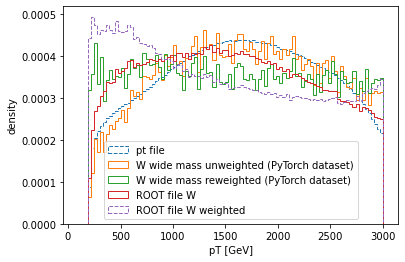

Dataset: W real mass
Selected parameters for signal: W

Using histogram file: ./histos/WBSMP8.root
Check if the data used to create the histogram contains jets with pT below the config file minimum.
If not, then the count for the first non-zero bin in the histogram is too low and results in the calculated flat-pT weights being too high for low-pT jets.
Different mass cuts result in different pT distributions.

Loading graphs file: /eos/home-t/tmlinare/Lund/Lund_tagging/lundtoptagger_data/graphs/ln_kT_cut_None_with_pt_200_with_dsids_mcweights_new_pt_weights_2025-03-07/graphs_Wrealmass_1-2_ln_kT_cut_None_with_pt_200_with_dsids_mcweights_new_pt_weights_2025-03-07
Jets with pT outside this range may not have correct weights applied.
Minimum pT in dataset: 200.550453125 GeV, Maximum pT in dataset: 3199.42725 GeV.
Check if the dataset is correctly filtered to match the config file parameters.
Minimum mass in dataset: 0.6144024658203125 GeV, Maximum mass in dataset: 1497.652625 GeV.
Check if 

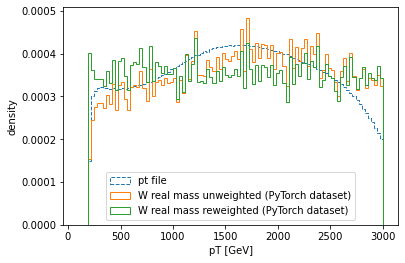

In [8]:
hist_params = dict(bins=100, histtype="step", density=True)

for dataset_label in datasets:
    print("Dataset:", dataset_label)

    # get the signal configuration from the YAML file
    with open("configs/config_signal.yaml") as f:
        config_signal = yaml.load(f, Loader=yaml.FullLoader)
    signal = datasets[dataset_label]["config_signal"]
    print("Selected parameters for signal:", signal)
    pt_min, pt_max = config_signal[signal]["pt_range"]
    m_min, m_max = config_signal[signal]["mass_range"]

    # plot histogram from hist file
    hist_filename = config_signal[signal]["pt_hist_file_signal"]
    print("\nUsing histogram file:", hist_filename)
    hist_file = uproot.open(hist_filename)

    bin_counts, bin_edges = hist_file["pt"].to_numpy()
    hist_pt_min_nonzero = bin_edges[np.nonzero(bin_counts)[0][0]]
    hist_pt_max_nonzero = bin_edges[np.nonzero(bin_counts)[0][-1]+1]

    bin_counts_mass, bin_edges_mass = hist_file["mass"].to_numpy()
    hist_mass_min_nonzero = bin_edges_mass[np.nonzero(bin_counts_mass)[0][0]]
    hist_mass_max_nonzero = bin_edges_mass[np.nonzero(bin_counts_mass)[0][-1]+1]

    if hist_pt_min_nonzero > pt_min or hist_pt_max_nonzero < pt_max:
        print(f"WARNING: pT histogram range with non-zero bin counts, {hist_pt_min_nonzero}-{hist_pt_max_nonzero} GeV, does not cover the config file range {pt_min}-{pt_max} GeV.")
    if hist_pt_min_nonzero < pt_min:
        print(f"WARNING: pT histogram range with non-zero bin counts starts at {hist_pt_min_nonzero} GeV, which is below the config file minimum {pt_min} GeV.")
        print("Check if the data used to create the histogram contains jets with pT below the config file minimum.")
        print("If not, then the count for the first non-zero bin in the histogram is too low and results in the calculated flat-pT weights being too high for low-pT jets.")

    if hist_mass_min_nonzero != m_min or hist_mass_max_nonzero != m_max:
        print(f"WARNING: mass histogram range with non-zero bin counts, {hist_mass_min_nonzero}-{hist_mass_max_nonzero} GeV, does not match file range {m_min}-{m_max} GeV.")
        print("Different mass cuts result in different pT distributions.")

    hist_params["bins"] = bin_edges
    plt.hist(bin_edges[:-1], weights=bin_counts, label="pt file", linestyle="--", **hist_params)

    # plot pT distribution from PyTorch dataset
    graphs_filname = datasets[dataset_label]["graphs_file"]
    print("\nLoading graphs file:", graphs_filname)
    dataset = torch.load(graphs_filname)
    pts = np.array([jet.pt for jet in dataset])
    masses = np.array([jet.mass for jet in dataset])
    weights = np.array([jet.weights for jet in dataset])
    ys = np.array([jet.y for jet in dataset])

    if pts.min() < pt_min or pts.max() > pt_max:
        # TODO: or should I compare with hist_pt_min_nonzero and hist_pt_max_nonzero?
        print(f"WARNING: pT values in dataset are outside the configured range {pt_min}-{pt_max} GeV.")
        print("Jets with pT outside this range may not have correct weights applied.")
        print(f"Minimum pT in dataset: {pts.min()} GeV, Maximum pT in dataset: {pts.max()} GeV.")
        print("Check if the dataset is correctly filtered to match the config file parameters.")

    if masses.min() < m_min or masses.max() > m_max:
        # TODO: or should I compare with hist_pt_min_nonzero and hist_pt_max_nonzero?
        print(f"WARNING: mass values in dataset are outside the configured range {m_min}-{m_max} GeV.")
        print(f"Minimum mass in dataset: {masses.min()} GeV, Maximum mass in dataset: {masses.max()} GeV.")
        print("Check if the dataset is correctly filtered to match the config file parameters.")

    plt.hist(pts[ys==1], **hist_params, label=dataset_label+" unweighted (PyTorch dataset)")
    plt.hist(pts[ys==1], weights=weights[ys==1], **hist_params, label=dataset_label+" reweighted (PyTorch dataset)")

    # plot pT distribution from original ROOT file
    if "ROOT_file" in datasets[dataset_label]:
        signal_jet_truth_label = config_signal[signal]["signal_jet_truth_label"]

        ROOT_file = datasets[dataset_label]["ROOT_file"]
        print("\nLoading ROOT file:", ROOT_file)

        with uproot.open(ROOT_file) as infile:
            tree = infile["AnalysisTree"]
            jet_pts = ak.flatten(tree["LRJ_pt"].array(library="ak"))
            jet_masses = ak.flatten(tree["LRJ_mass"].array(library="ak"))
            truth_labels = ak.flatten(tree["LRJ_truthLabel"].array(library="ak"))

        mass_selection = (jet_masses > m_min) & (jet_masses < m_max)
        plt.hist(jet_pts[(truth_labels==signal_jet_truth_label) & mass_selection], label="ROOT file W", **hist_params)

    if dataset_label == "W wide mass":
        pt_weights = flat_weights[(truth_labels==signal_jet_truth_label) & mass_selection]
        plt.hist(jet_pts[(truth_labels==signal_jet_truth_label) & mass_selection], weights=pt_weights, **hist_params, label="ROOT file W weighted", linestyle="--")

    plt.xlabel("pT [GeV]")
    plt.ylabel("density")
    plt.legend()
    # plt.savefig(f"tests/pt_hist_{dataset_label.replace(' ', '_')}.pdf")
    plt.show()